# Self-pacing & the funny current

Every action potential so far has needed an **electrode**: we injected a stimulus to fire the cell.
But the heart doesn't wait to be poked — its pacemaker cells fire *by themselves*, over and over,
setting the rhythm of the whole organ. So do the human stem-cell-derived heart cells (**hiPSC-CMs**)
grown in dishes and on tissue chips, which is exactly why they are so useful in the lab: put them in a
dish and they beat spontaneously.

This short advanced notebook switches from the adult-ventricle `ttp06` model to **`paci`** (Paci et
al. 2013), a model of a spontaneously-active hiPSC cardiomyocyte. We'll watch it beat on its own with
no stimulus at all, then meet the current most responsible for that automaticity — the delightfully
named **"funny" current, `I_f`** — and slow the cell's rhythm by turning it down.

**What you'll learn**

1. **Automaticity** — run a cell that fires repeatedly with `stim_amplitude=0` (no electrode)
2. **Diastolic depolarisation** — the slow drift toward threshold that *is* the pacemaker
3. **The funny current `g_f`** — scale it and watch the spontaneous rate change

**Runtime**: about half a minute (two short runs). The Paci model is stiffer than `ttp06`, so we use a
larger step `dt=0.1` and a few seconds of simulated time to capture several spontaneous beats.

---
## Setup

Install `cardiac_core` if needed (a no-op if you already have it), then import it as `cc`.

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
# If it is already installed, this does nothing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core — this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/RealJokerInc/cardiac-core.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. A cell that beats on its own

The single change that makes this notebook different from Chapter 2 is one keyword:
**`stim_amplitude=0.0`** — no stimulus current at all. A `ttp06` cell given no stimulus would just sit
at rest forever. A `paci` cell doesn't: it fires anyway. We simulate 3.5 seconds so several beats fit,
at the larger step `dt=0.1` the stiffer model is happy with.

most negative point (MDP) = -77 mV   peak = 28 mV


ImageInfo(unsaved, 887x508, panels=1, 35,925 bytes)
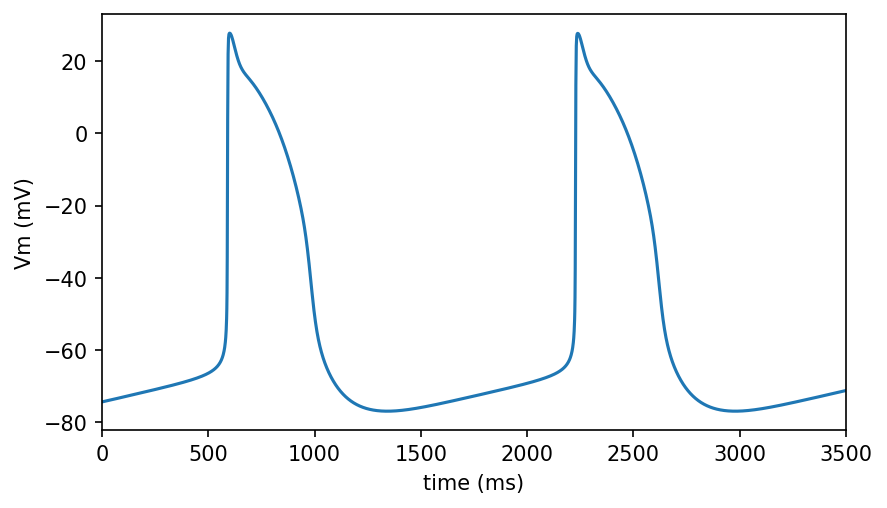

In [3]:
paci = cc.single_cell(
    "paci",                 # a spontaneously-active hiPSC cardiomyocyte model
    stim_amplitude=0.0,     # NO electrode — the cell fires on its own
    n_beats=1, bcl=3500,    # record one 3.5-second stretch
    dt=0.1,                 # larger step for the stiffer Paci model
)

print(f"most negative point (MDP) = {paci.v_rest:.0f} mV   peak = {paci.v_peak:.0f} mV")
paci.trace(xlim=(0, 3500))

No electrode, and yet the cell fires — **twice** in this window, entirely on its own. That is
**automaticity**. Look closely at what happens *between* the spikes: the voltage never sits still.
After each beat the cell relaxes to its most-negative point (the **maximum diastolic potential**, about
**-77 mV** here) and then immediately begins a slow, steady climb back up. That upward creep is
**diastolic depolarisation** — the pacemaker ramp. When it drags the voltage up to threshold (~-60 mV),
the next spike fires, and the cycle repeats.

The two upstrokes here sit about **1.6 seconds apart** (at ~590 ms and ~2230 ms), so this cell is
free-running at roughly **0.6 Hz — about 37 beats per minute**. The whole rhythm is set by *how steeply*
that diastolic ramp climbs: a steeper climb reaches threshold sooner and beats faster.

---
## 2. The funny current sets the pace

What drives the diastolic ramp? Several currents contribute, but the emblematic one is the **"funny"
current `I_f`** — funny because, unlike most channels, it switches *on* at negative voltages, so it
turns on right after a beat and carries the cell back upward toward the next one. It is the classic
"pacemaker current," and the heart-rate-lowering drug **ivabradine** works by blocking exactly this
current.

In `paci` its conductance is **`g_f`**. (Note the lower-case `g_` — the hiPSC models name their
channels differently from `ttp06`'s upper-case `G`; more on that below.) Let's turn it down to a
quarter and overlay the result on the free-running baseline.

ImageInfo(unsaved, 887x508, panels=1, 54,225 bytes)
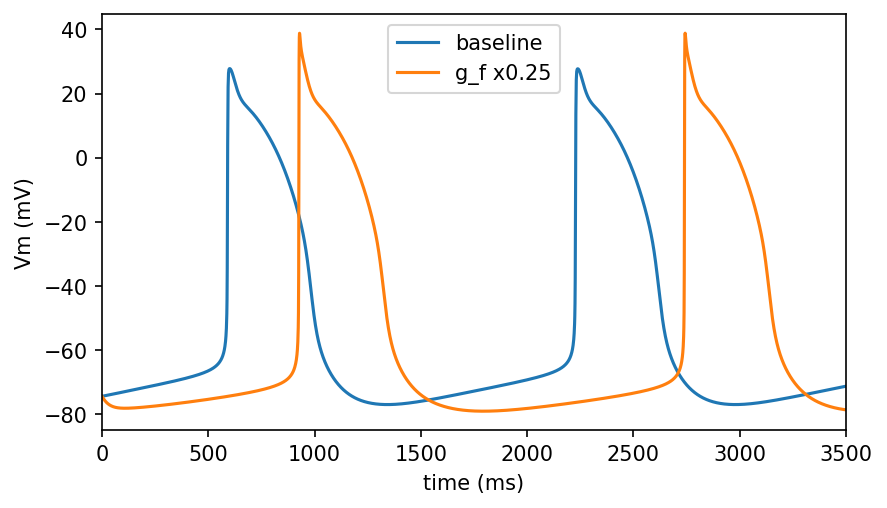

diastolic low point:  baseline = -77 mV,  g_f-blocked = -79 mV


In [4]:
slow = cc.single_cell("paci", stim_amplitude=0.0, n_beats=1, bcl=3500, dt=0.1,
                      conductances={"g_f": 0.25})   # 75% block of the funny current

cc.draw(cc.Trace({"baseline": (paci.times, paci.V),
                  "g_f x0.25": (slow.times, slow.V)},
                 xlabel="time (ms)", ylabel="Vm (mV)", xlim=(0, 3500))).show()   # .show() renders it even though a print() follows

print(f"diastolic low point:  baseline = {paci.v_rest:.0f} mV,  g_f-blocked = {slow.v_rest:.0f} mV")

With the funny current cut to a quarter, the diastolic ramp climbs more slowly, so the cell
takes **longer to reach threshold** — every beat is delayed. The first spontaneous beat slips from
~590 ms to ~925 ms, and the beat-to-beat interval stretches from about **1.64 s to 1.81 s** (roughly
**0.61 → 0.55 Hz**, ~37 → ~33 beats per minute). The cell also settles a little deeper between beats
(the printed diastolic low point drops from about **-77 mV to -79 mV**). Because each beat is a little
later than the last, the orange trace drifts steadily to the right of the blue one — a slower pacemaker,
drawn out in front of you. Block the funny current and the heart slows: that is ivabradine in one picture.

---
## A note on names: hiPSC models use lower-case `g_`

The name-validation you can trust from Chapter 2 lists *this* model's channels. Because `paci` names
its conductances lower-case (`g_Na`, `g_Kr`, `g_f`, …) rather than `ttp06`'s upper-case (`GNa`, `GKr`),
using a `ttp06`-style name here is a typo — and, as before, it is caught, not ignored. Run this to see
the funny-current cell's real vocabulary printed back at you:

In [5]:
try:
    cc.single_cell("paci", stim_amplitude=0.0, conductances={"g_F": 0.25})   # wrong case for Paci
except ValueError as e:
    print("Rejected (note the available names are the hiPSC lower-case set):\n", e)

Rejected (note the available names are the hiPSC lower-case set):
 'g_F' is not a scalable conductance of PHAS13Model; available conductances: ['PNaK', 'g_CaL', 'g_K1', 'g_Kr', 'g_Ks', 'g_Na', 'g_bCa', 'g_bNa', 'g_f', 'g_pCa', 'g_to']


---
### Try it yourself

1. **Speed it up instead.** In the section-2 cell, change `{"g_f": 0.25}` to `{"g_f": 1.5}`. A
   *stronger* funny current makes the diastolic ramp steeper, so the cell reaches threshold sooner and
   beats *faster* — the opposite of ivabradine.
2. **Silence the pacemaker.** Try a very deep block, `{"g_f": 0.05}`. The ramp becomes so shallow the
   cell may barely reach threshold in the window — automaticity can fail when the pacemaker current is
   gone.
3. **Watch it longer.** Raise `bcl=3500` to `bcl=6000` in both cells to capture more beats and see the
   rate difference accumulate. (It costs a little more runtime — the run is proportional to the window.)

---
## Recap

- Some heart cells — real pacemaker cells, and hiPSC-CMs in a dish — **fire on their own**. Run one
  with `stim_amplitude=0.0` (no electrode) and it beats repeatedly: **automaticity**.
- The rhythm comes from **diastolic depolarisation**, the slow climb from the diastolic potential up to
  threshold between beats. Steeper climb → faster rate.
- The **funny current `I_f`** (conductance `g_f`) is the emblematic pacemaker current. Blocking it
  (`conductances={"g_f": 0.25}`) flattens the ramp and **slows the rate** — the mechanism of ivabradine.
- hiPSC models name their channels **lower-case `g_*`**; a wrong-case name is a typo, and it is caught.

**Where next**: you have now met the cell from two sides — what shapes one beat (Chapter 2) and what
sets the rhythm of many (here). Chapter 3 leaves the single cell behind and builds **tissue**, where
these cells are wired together and a beat becomes a travelling *wave*.